# 05. Sparkov Class-Imbalance Strategies

This notebook compares several ways to handle severe class imbalance in the Sparkov fraud-detection problem.

Fraud is rare compared with legitimate transactions, so a model can appear strong under some metrics even when it misses many fraud cases.

## Main Research Question

> How do different class-imbalance strategies affect future-period fraud ranking, threshold behavior, and probability quality?

## Strategies Compared

1. **Unweighted LightGBM**
2. **Weighted LightGBM** using `scale_pos_weight`
3. **Random undersampling + LightGBM**

## Core Leakage Rule

Any class rebalancing is applied **only to Train**.

Calibration, Validation, and Test retain their natural fraud prevalence.

## Why This Matters

Changing the class distribution can improve fraud ranking or recall, but it can also distort predicted probabilities.

That is why this notebook records both:

- ranking metrics such as PR-AUC
- probability-quality metrics such as Brier Score and Log Loss

Probability calibration is handled later in Notebook 06.

## Test Set Lock

The Test period remains untouched in this notebook.

All strategy selection is based on Validation only.

## 1. Import Libraries and Create Output Folders

This notebook recreates the same data preparation, temporal split, and past-only features used in the earlier notebooks so it can run independently in Kaggle.

In [5]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    precision_recall_curve,
)

from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load and Clean the Sparkov Dataset

In [6]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop(
    columns=[c for c in df.columns if c.lower().startswith("unnamed")],
    errors="ignore"
)

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"], errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"], errors="coerce"
)

df["merchant_clean"] = (
    df["merchant"]
    .astype(str)
    .str.replace(r"^fraud_", "", regex=True)
)

df = (
    df.sort_values(["unix_time", "trans_num"])
      .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Shape:", df.shape)
print("Fraud rate:", df["is_fraud"].mean())

Shape: (1296675, 24)
Fraud rate: 0.005788651743883394


## 3. Recreate Current-Transaction Features

These are the same current-transaction features used in Notebook 03 and Notebook 04.

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371 * 2 * np.arcsin(np.sqrt(a))


df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days
    / 365.25
)

df["distance_home_to_merchant_km"] = haversine_km(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

print("Current-transaction features created.")

Current-transaction features created.


## 4. Recreate Leakage-Safe Past-Only Features

Every historical feature excludes the current transaction and uses only earlier transactions.

No historical fraud labels are used.

In [8]:
def add_past_only_features(data):
    data = (
        data.sort_values(["unix_time", "trans_num"])
        .reset_index(drop=True)
        .copy()
    )

    card_group = data.groupby("cc_num", sort=False)

    data["card_tx_count_before"] = card_group.cumcount()
    data["card_has_history"] = (
        data["card_tx_count_before"] > 0
    ).astype("int8")

    data["card_prev_unix_time"] = (
        card_group["unix_time"].shift(1)
    )

    data["card_time_since_prev_hours"] = (
        data["unix_time"] - data["card_prev_unix_time"]
    ) / 3600.0

    data["_amt_sq"] = data["amt"] ** 2

    data["_card_amt_sum_before"] = (
        card_group["amt"].cumsum() - data["amt"]
    )

    data["_card_amt_sq_sum_before"] = (
        data.groupby("cc_num", sort=False)["_amt_sq"].cumsum()
        - data["_amt_sq"]
    )

    previous_count = (
        data["card_tx_count_before"]
        .replace(0, np.nan)
    )

    data["card_amt_mean_before"] = (
        data["_card_amt_sum_before"] / previous_count
    )

    previous_second_moment = (
        data["_card_amt_sq_sum_before"] / previous_count
    )

    previous_variance = (
        previous_second_moment
        - data["card_amt_mean_before"] ** 2
    ).clip(lower=0)

    data["card_amt_std_before"] = np.sqrt(previous_variance)

    data["card_amt_ratio_to_mean"] = (
        data["amt"]
        / data["card_amt_mean_before"].replace(0, np.nan)
    )

    data["card_amt_zscore_before"] = (
        (data["amt"] - data["card_amt_mean_before"])
        / data["card_amt_std_before"].replace(0, np.nan)
    )

    data["card_merchant_pair_count_before"] = (
        data.groupby(
            ["cc_num", "merchant_clean"],
            sort=False
        ).cumcount()
    )

    data["card_new_merchant"] = (
        data["card_merchant_pair_count_before"] == 0
    ).astype("int8")

    data["_merchant_first_for_card"] = (
        data["card_merchant_pair_count_before"] == 0
    ).astype("int8")

    data["card_distinct_merchants_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_merchant_first_for_card"].cumsum()
        - data["_merchant_first_for_card"]
    )

    data["card_category_pair_count_before"] = (
        data.groupby(
            ["cc_num", "category"],
            sort=False
        ).cumcount()
    )

    data["card_new_category"] = (
        data["card_category_pair_count_before"] == 0
    ).astype("int8")

    data["_category_first_for_card"] = (
        data["card_category_pair_count_before"] == 0
    ).astype("int8")

    data["card_distinct_categories_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_category_first_for_card"].cumsum()
        - data["_category_first_for_card"]
    )

    merchant_group = data.groupby("merchant_clean", sort=False)

    data["merchant_tx_count_before"] = merchant_group.cumcount()

    data["_merchant_amt_sum_before"] = (
        merchant_group["amt"].cumsum() - data["amt"]
    )

    merchant_previous_count = (
        data["merchant_tx_count_before"]
        .replace(0, np.nan)
    )

    data["merchant_amt_mean_before"] = (
        data["_merchant_amt_sum_before"]
        / merchant_previous_count
    )

    helper_cols = [
        "_amt_sq",
        "_card_amt_sum_before",
        "_card_amt_sq_sum_before",
        "_merchant_first_for_card",
        "_category_first_for_card",
        "_merchant_amt_sum_before",
    ]

    return data.drop(columns=helper_cols)


df = add_past_only_features(df)

print("Past-only features created.")

Past-only features created.


## 5. Recreate the Fixed Chronological Split

The split design remains unchanged:

- Train: 60%
- Calibration: 15%
- Validation: 10%
- Test: 15%
- 24-hour total purge window around each boundary

Only Train will be rebalanced.

In [9]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

PURGE_HOURS = 24
HALF_PURGE_SECONDS = int((PURGE_HOURS / 2) * 3600)

n = len(df)

train_boundary_idx = int(n * TRAIN_RATIO)
calibration_boundary_idx = int(
    n * (TRAIN_RATIO + CALIBRATION_RATIO)
)
validation_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
        + VALIDATION_RATIO
    )
)

train_boundary = int(df.iloc[train_boundary_idx]["unix_time"])
calibration_boundary = int(
    df.iloc[calibration_boundary_idx]["unix_time"]
)
validation_boundary = int(
    df.iloc[validation_boundary_idx]["unix_time"]
)

train = df[
    df["unix_time"] < train_boundary - HALF_PURGE_SECONDS
].copy()

calibration = df[
    (df["unix_time"] > train_boundary + HALF_PURGE_SECONDS)
    & (df["unix_time"] < calibration_boundary - HALF_PURGE_SECONDS)
].copy()

validation = df[
    (df["unix_time"] > calibration_boundary + HALF_PURGE_SECONDS)
    & (df["unix_time"] < validation_boundary - HALF_PURGE_SECONDS)
].copy()

test = df[
    df["unix_time"] > validation_boundary + HALF_PURGE_SECONDS
].copy()

assert train["unix_time"].max() < calibration["unix_time"].min()
assert calibration["unix_time"].max() < validation["unix_time"].min()
assert validation["unix_time"].max() < test["unix_time"].min()

print({
    "train": len(train),
    "calibration": len(calibration),
    "validation": len(validation),
    "test": len(test),
})

{'train': 777050, 'calibration': 192249, 'validation': 128128, 'test': 193574}


## 6. Inspect Natural Class Prevalence

Calibration, Validation, and Test must keep their natural prevalence.

We do not rebalance evaluation data.

In [10]:
def class_summary(name, data):
    fraud = int(data["is_fraud"].sum())
    legit = int((data["is_fraud"] == 0).sum())

    return {
        "split": name,
        "rows": len(data),
        "legitimate": legit,
        "fraud": fraud,
        "fraud_rate": fraud / len(data),
        "legitimate_to_fraud_ratio": (
            legit / fraud if fraud > 0 else np.nan
        ),
    }

natural_class_summary = pd.DataFrame([
    class_summary("train", train),
    class_summary("calibration", calibration),
    class_summary("validation", validation),
    class_summary("test", test),
])

display(natural_class_summary)

,split,rows,legitimate,fraud,fraud_rate,legitimate_to_fraud_ratio
0,train,777050,772466,4584,0.005899,168.513525
1,calibration,192249,191330,919,0.004780,208.193689
2,validation,128128,127285,843,0.006579,150.990510
3,test,193574,192448,1126,0.005817,170.912966


## 7. Define the Feature Set

This notebook uses the current + past-only feature set established in Notebook 04.

That keeps class imbalance as the main experimental change.

In [11]:
current_numeric_features = [
    "amt",
    "city_pop",
    "age",
    "distance_home_to_merchant_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

past_only_numeric_features = [
    "card_tx_count_before",
    "card_has_history",
    "card_time_since_prev_hours",
    "card_amt_mean_before",
    "card_amt_std_before",
    "card_amt_ratio_to_mean",
    "card_amt_zscore_before",
    "card_merchant_pair_count_before",
    "card_new_merchant",
    "card_distinct_merchants_before",
    "card_category_pair_count_before",
    "card_new_category",
    "card_distinct_categories_before",
    "merchant_tx_count_before",
    "merchant_amt_mean_before",
]

categorical_features = [
    "category",
    "merchant_clean",
    "state",
    "job",
]

numeric_features = (
    current_numeric_features
    + past_only_numeric_features
)

feature_cols = numeric_features + categorical_features

TARGET = "is_fraud"

print("Total features:", len(feature_cols))

Total features: 30


## 8. Fit Preprocessing on the Natural Train Set

To keep the imbalance comparison fair:

1. preprocessing is fitted on the full natural Train set
2. Train and Validation are transformed
3. undersampling is applied only to transformed Train rows

This prevents imputation and category encoding from being learned from an artificial resampled class distribution.

In [12]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

X_train = train[feature_cols]
y_train = train[TARGET].reset_index(drop=True)

X_val = validation[feature_cols]
y_val = validation[TARGET].reset_index(drop=True)

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)

validation_amount = validation["amt"].to_numpy()

print("Encoded Train shape:", X_train_encoded.shape)
print("Encoded Validation shape:", X_val_encoded.shape)

Encoded Train shape: (777050, 30)
Encoded Validation shape: (128128, 30)


## 9. Define Evaluation Metrics

PR-AUC is the primary ranking metric.

We also record:

- ROC-AUC
- Precision
- Recall
- F1
- Brier Score
- Log Loss
- Alert rate
- Fraud Amount Recall

Threshold 0.5 is only a reference. Final threshold tuning happens later.

In [13]:
def fraud_amount_recall(y_true, pred, amount):
    y = np.asarray(y_true)
    pred = np.asarray(pred)
    amount = np.asarray(amount)

    total_fraud_amount = amount[y == 1].sum()

    if total_fraud_amount == 0:
        return np.nan

    detected_amount = amount[
        (y == 1) & (pred == 1)
    ].sum()

    return detected_amount / total_fraud_amount


def evaluate_model(
    model_name,
    y_true,
    proba,
    amount,
    threshold=0.5
):
    proba = np.asarray(proba)
    pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "precision": precision_score(
            y_true, pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, pred, zero_division=0
        ),
        "brier": brier_score_loss(y_true, proba),
        "log_loss": log_loss(
            y_true,
            np.clip(proba, 1e-8, 1 - 1e-8)
        ),
        "alert_rate": float(pred.mean()),
        "fraud_amount_recall": fraud_amount_recall(
            y_true, pred, amount
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

## 10. Strategy A — Unweighted LightGBM

This is the reference strategy.

The model trains on the natural class distribution without weighting or resampling.

In [14]:
common_params = dict(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

unweighted_model = LGBMClassifier(**common_params)

unweighted_model.fit(
    X_train_encoded,
    y_train
)

unweighted_val_proba = (
    unweighted_model.predict_proba(
        X_val_encoded
    )[:, 1]
)

unweighted_metrics = evaluate_model(
    "Unweighted LightGBM",
    y_val,
    unweighted_val_proba,
    validation_amount
)

unweighted_metrics

{'model': 'Unweighted LightGBM',
 'threshold': 0.5,
 'roc_auc': np.float64(0.9980606657396504),
 'pr_auc': np.float64(0.9285856407042714),
 'precision': 0.978125,
 'recall': 0.7425860023724793,
 'f1': 0.8442346594740391,
 'brier': np.float64(0.0015207037828565953),
 'log_loss': 0.006812056854768426,
 'alert_rate': 0.004995004995004995,
 'fraud_amount_recall': np.float64(0.8098884198255863),
 'true_negative': 127271,
 'false_positive': 14,
 'false_negative': 217,
 'true_positive': 626}

## 11. Strategy B — Weighted LightGBM

For the weighted model:

\[
\text{scale\_pos\_weight}
=
\frac{\text{legitimate Train transactions}}
{\text{fraud Train transactions}}
\]

This increases the training importance of fraud examples while keeping all Train rows.

Weighted probabilities may be less calibrated, so probability quality is inspected but not finalized here.

In [15]:
train_legitimate = int((y_train == 0).sum())
train_fraud = int((y_train == 1).sum())

scale_pos_weight = (
    train_legitimate / train_fraud
)

print("Train legitimate:", train_legitimate)
print("Train fraud:", train_fraud)
print("scale_pos_weight:", scale_pos_weight)

Train legitimate: 772466
Train fraud: 4584
scale_pos_weight: 168.51352530541013


In [16]:
weighted_model = LGBMClassifier(
    **common_params,
    scale_pos_weight=scale_pos_weight
)

weighted_model.fit(
    X_train_encoded,
    y_train
)

weighted_val_proba = (
    weighted_model.predict_proba(
        X_val_encoded
    )[:, 1]
)

weighted_metrics = evaluate_model(
    "Weighted LightGBM",
    y_val,
    weighted_val_proba,
    validation_amount
)

weighted_metrics

{'model': 'Weighted LightGBM',
 'threshold': 0.5,
 'roc_auc': np.float64(0.995793208569648),
 'pr_auc': np.float64(0.9059614490491927),
 'precision': 0.8391356542617047,
 'recall': 0.8291814946619217,
 'f1': 0.834128878281623,
 'brier': np.float64(0.0016793335769765031),
 'log_loss': 0.0068770146566155535,
 'alert_rate': 0.006501311188811189,
 'fraud_amount_recall': np.float64(0.8863779333467611),
 'true_negative': 127151,
 'false_positive': 134,
 'false_negative': 144,
 'true_positive': 699}

## 12. Strategy C — Random Undersampling

This experiment keeps:

- every fraud Train transaction
- a random subset of legitimate Train transactions

We use a controlled **5 legitimate : 1 fraud** Train ratio.

This is a sensitivity experiment, not a claim that 5:1 is universally optimal.

In [17]:
UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO = 5

rng = np.random.default_rng(SEED)

fraud_positions = np.where(
    y_train.to_numpy() == 1
)[0]

legitimate_positions = np.where(
    y_train.to_numpy() == 0
)[0]

desired_legitimate_count = min(
    len(legitimate_positions),
    len(fraud_positions)
    * UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO
)

sampled_legitimate_positions = rng.choice(
    legitimate_positions,
    size=desired_legitimate_count,
    replace=False
)

undersample_positions = np.concatenate([
    fraud_positions,
    sampled_legitimate_positions,
])

rng.shuffle(undersample_positions)

X_train_under = X_train_encoded[
    undersample_positions
]

y_train_under = (
    y_train.iloc[undersample_positions]
    .reset_index(drop=True)
)

print("Original Train rows:", len(y_train))
print("Undersampled Train rows:", len(y_train_under))
print(y_train_under.value_counts().sort_index())

assert (
    (y_train_under == 1).sum()
    == (y_train == 1).sum()
)

print("All Train fraud rows retained.")

Original Train rows: 777050
Undersampled Train rows: 27504
is_fraud
0    22920
1     4584
Name: count, dtype: int64
All Train fraud rows retained.


In [18]:
undersampled_model = LGBMClassifier(**common_params)

undersampled_model.fit(
    X_train_under,
    y_train_under
)

undersampled_val_proba = (
    undersampled_model.predict_proba(
        X_val_encoded
    )[:, 1]
)

undersampled_metrics = evaluate_model(
    "Undersampled LightGBM",
    y_val,
    undersampled_val_proba,
    validation_amount
)

undersampled_metrics

{'model': 'Undersampled LightGBM',
 'threshold': 0.5,
 'roc_auc': np.float64(0.9984244825468258),
 'pr_auc': np.float64(0.9231410118040965),
 'precision': 0.6440397350993378,
 'recall': 0.9228944246737841,
 'f1': 0.7586543149683082,
 'brier': np.float64(0.0030104386151465776),
 'log_loss': 0.010969577805856187,
 'alert_rate': 0.009428071928071928,
 'fraud_amount_recall': np.float64(0.977958658550581),
 'true_negative': 126855,
 'false_positive': 430,
 'false_negative': 65,
 'true_positive': 778}

## 13. Compare All Three Strategies

The main comparison is Validation PR-AUC.

Brier Score and Log Loss are also important because rebalancing can distort raw probabilities.

In [19]:
imbalance_results = pd.DataFrame([
    unweighted_metrics,
    weighted_metrics,
    undersampled_metrics,
])

imbalance_results = (
    imbalance_results
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(imbalance_results)

,model,threshold,roc_auc,pr_auc,precision,recall,f1,brier,log_loss,alert_rate,fraud_amount_recall,true_negative,false_positive,false_negative,true_positive
0,Unweighted LightGBM,0.5,0.998061,0.928586,0.978125,0.742586,0.844235,0.001521,0.006812,0.004995,0.809888,127271,14,217,626
1,Undersampled LightGBM,0.5,0.998424,0.923141,0.644040,0.922894,0.758654,0.003010,0.010970,0.009428,0.977959,126855,430,65,778
2,Weighted LightGBM,0.5,0.995793,0.905961,0.839136,0.829181,0.834129,0.001679,0.006877,0.006501,0.886378,127151,134,144,699


## 14. Select the Imbalance Strategy on Validation

For this project, the imbalance strategy is selected by Validation PR-AUC.

The Test set is not used.

In [20]:
selected_strategy = (
    imbalance_results
    .iloc[0]["model"]
)

print(
    "Selected imbalance strategy by Validation PR-AUC:",
    selected_strategy
)

Selected imbalance strategy by Validation PR-AUC: Unweighted LightGBM


## 15. Precision-Recall Curves

The PR curves show whether the strategies differ across many thresholds rather than only at threshold 0.5.

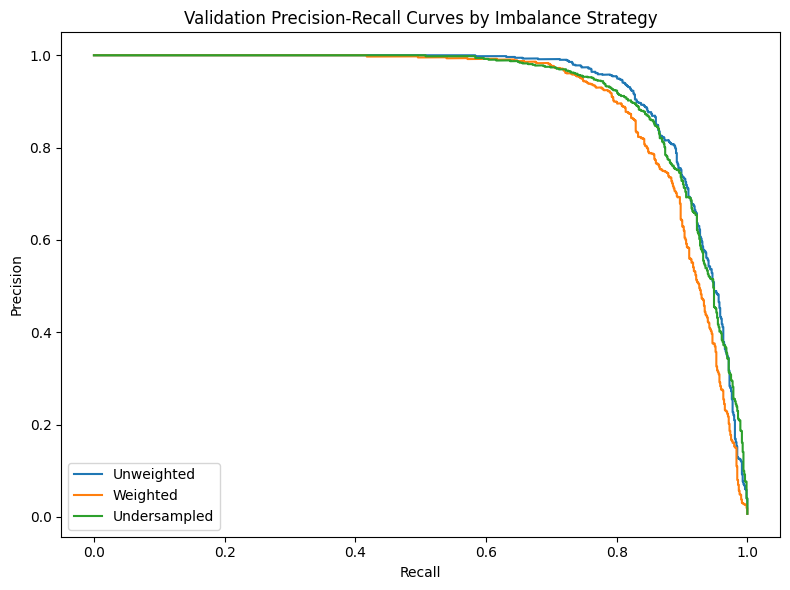

In [21]:
plt.figure(figsize=(8, 6))

for name, proba in [
    ("Unweighted", unweighted_val_proba),
    ("Weighted", weighted_val_proba),
    ("Undersampled", undersampled_val_proba),
]:
    precision, recall, _ = precision_recall_curve(
        y_val,
        proba
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Validation Precision-Recall Curves by Imbalance Strategy"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/imbalance_pr_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 16. PR-AUC Comparison Figure

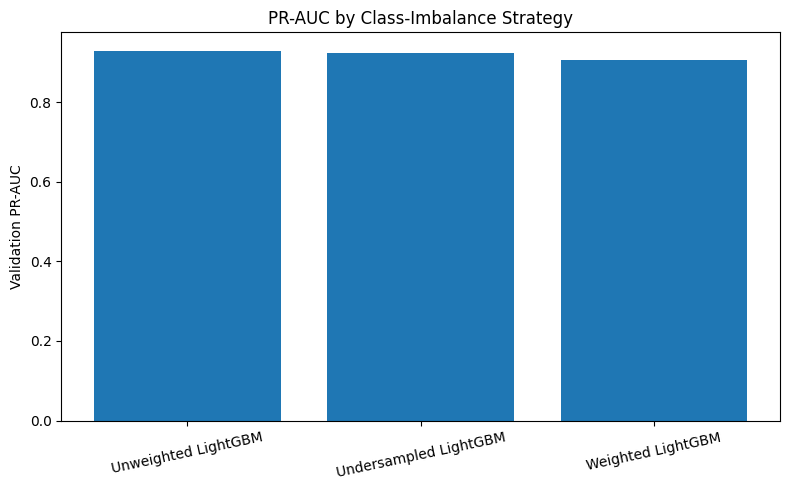

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    imbalance_results["model"],
    imbalance_results["pr_auc"]
)

plt.ylabel("Validation PR-AUC")
plt.title("PR-AUC by Class-Imbalance Strategy")
plt.xticks(rotation=12)
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/imbalance_pr_auc_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 17. Probability-Quality Comparison

Lower Brier Score is better.

A strategy may improve ranking while worsening raw probability quality.

Notebook 06 will explicitly calibrate probabilities.

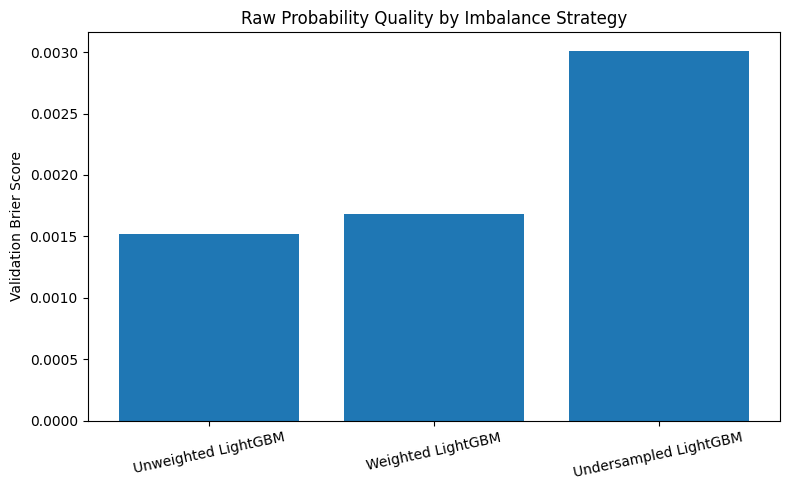

In [23]:
brier_plot = (
    imbalance_results[
        ["model", "brier"]
    ]
    .sort_values(
        "brier",
        ascending=True
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    brier_plot["model"],
    brier_plot["brier"]
)

plt.ylabel("Validation Brier Score")
plt.title("Raw Probability Quality by Imbalance Strategy")
plt.xticks(rotation=12)
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/imbalance_brier_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 18. Inspect Predicted-Probability Distributions

Weighted and undersampled models may produce systematically larger probabilities because their training objectives differ from the natural prevalence.

In [24]:
probability_summary = pd.DataFrame([
    {
        "model": "Unweighted LightGBM",
        "mean_probability": float(np.mean(unweighted_val_proba)),
        "median_probability": float(np.median(unweighted_val_proba)),
        "p95_probability": float(np.quantile(unweighted_val_proba, 0.95)),
        "p99_probability": float(np.quantile(unweighted_val_proba, 0.99)),
    },
    {
        "model": "Weighted LightGBM",
        "mean_probability": float(np.mean(weighted_val_proba)),
        "median_probability": float(np.median(weighted_val_proba)),
        "p95_probability": float(np.quantile(weighted_val_proba, 0.95)),
        "p99_probability": float(np.quantile(weighted_val_proba, 0.99)),
    },
    {
        "model": "Undersampled LightGBM",
        "mean_probability": float(np.mean(undersampled_val_proba)),
        "median_probability": float(np.median(undersampled_val_proba)),
        "p95_probability": float(np.quantile(undersampled_val_proba, 0.95)),
        "p99_probability": float(np.quantile(undersampled_val_proba, 0.99)),
    },
])

display(probability_summary)

,model,mean_probability,median_probability,p95_probability,p99_probability
0,Unweighted LightGBM,0.005124,0.000010,0.000365,0.007957
1,Weighted LightGBM,0.007548,0.000007,0.001519,0.127922
2,Undersampled LightGBM,0.011750,0.000054,0.008236,0.446697


## 19. Save Validation Predictions

These development predictions make the experiment auditable.

No Test predictions are generated here.

In [25]:
validation_predictions = validation[
    [
        "trans_num",
        "trans_date_trans_time",
        "cc_num",
        "merchant_clean",
        "is_fraud",
        "amt",
    ]
].copy()

validation_predictions[
    "unweighted_probability"
] = unweighted_val_proba

validation_predictions[
    "weighted_probability"
] = weighted_val_proba

validation_predictions[
    "undersampled_probability"
] = undersampled_val_proba

display(validation_predictions.head())

,trans_num,trans_date_trans_time,cc_num,merchant_clean,is_fraud,amt,unweighted_probability,weighted_probability,undersampled_probability
973144,4b76605c3b0d1af2eb0c4d65471a8507,2020-01-29 03:06:41,30234966027947,Hamill-Daugherty,0,64.48,0.000001,1.088534e-07,0.000007
973145,4bf9edc93a30609997e20b51463f235f,2020-01-29 03:08:10,30044330818990,Herzog Ltd,0,105.47,0.000029,1.215732e-05,0.000037
973146,0f954e9f95faf5c8c2fee730fd15f33c,2020-01-29 03:09:14,4464457352619,"Christiansen, Goyette and Schamberger",0,78.15,0.000002,1.456352e-06,0.000010
973147,77ae0fef10fe571fd75ce0bceac1cd68,2020-01-29 03:09:50,377993105397617,Friesen-Stamm,0,64.90,0.000007,1.715335e-05,0.000018
973148,8b60b26dee5e2e4a7d212b02ace322c5,2020-01-29 03:10:44,4169388510116,Prohaska-Murray,0,60.89,0.000003,8.523619e-05,0.000121


## 20. Save Experiment Configuration

In [26]:
imbalance_configuration = pd.DataFrame([
    {
        "setting": "train_legitimate_count",
        "value": train_legitimate,
    },
    {
        "setting": "train_fraud_count",
        "value": train_fraud,
    },
    {
        "setting": "scale_pos_weight",
        "value": scale_pos_weight,
    },
    {
        "setting": "undersample_legitimate_to_fraud_ratio",
        "value": UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO,
    },
    {
        "setting": "undersampled_train_rows",
        "value": len(y_train_under),
    },
    {
        "setting": "selected_strategy_by_validation_pr_auc",
        "value": selected_strategy,
    },
])

display(imbalance_configuration)

,setting,value
0,train_legitimate_count,772466
1,train_fraud_count,4584
2,scale_pos_weight,168.513525
3,undersample_legitimate_to_fraud_ratio,5
4,undersampled_train_rows,27504
5,selected_strategy_by_validation_pr_auc,Unweighted LightGBM


## 21. Save Results

### Results

- `imbalance_comparison.csv`
- `imbalance_probability_summary.csv`
- `imbalance_configuration.csv`
- `imbalance_validation_predictions.csv`
- `natural_class_summary.csv`

### Figures

- `imbalance_pr_curves.png`
- `imbalance_pr_auc_comparison.png`
- `imbalance_brier_comparison.png`

In [27]:
imbalance_results.to_csv(
    "/kaggle/working/results/imbalance_comparison.csv",
    index=False
)

probability_summary.to_csv(
    "/kaggle/working/results/imbalance_probability_summary.csv",
    index=False
)

imbalance_configuration.to_csv(
    "/kaggle/working/results/imbalance_configuration.csv",
    index=False
)

validation_predictions.to_csv(
    "/kaggle/working/results/imbalance_validation_predictions.csv",
    index=False
)

natural_class_summary.to_csv(
    "/kaggle/working/results/natural_class_summary.csv",
    index=False
)

print("Results:")
for filename in sorted(
    os.listdir("/kaggle/working/results")
):
    print("-", filename)

print("\nFigures:")
for filename in sorted(
    os.listdir("/kaggle/working/figures")
):
    print("-", filename)

Results:
- imbalance_comparison.csv
- imbalance_configuration.csv
- imbalance_probability_summary.csv
- imbalance_validation_predictions.csv
- natural_class_summary.csv

Figures:
- imbalance_brier_comparison.png
- imbalance_pr_auc_comparison.png
- imbalance_pr_curves.png


## 22. How to Interpret the Results

### If weighting performs best

The model benefits from emphasizing fraud observations while keeping all legitimate Train transactions.

### If undersampling performs best

A smaller majority class may help the model focus on fraud, but some legitimate information is discarded.

### If unweighted performs best

The baseline LightGBM may already rank fraud effectively without explicit rebalancing.

### If Brier Score worsens

That can happen even when PR-AUC improves.

Ranking and probability calibration are different properties.

## 23. Why SMOTE Is Not Included in the Main Sparkov Comparison

SMOTE creates synthetic minority examples by interpolation.

Sparkov includes categorical and transaction-history features, so interpolated synthetic rows may not correspond to realistic transaction histories.

For the main Sparkov analysis, this notebook therefore focuses on:

- no special rebalancing
- class weighting
- Train-only random undersampling

## 24. Leakage and Methodology Notes

- All rebalancing is Train-only.
- Validation remains at natural prevalence.
- Test remains locked.
- Preprocessing is fitted on natural Train before undersampling.
- Raw probabilities from weighted or undersampled models should not automatically be interpreted as real fraud probabilities.
- Probability calibration is handled separately in Notebook 06.

## 25. Limitations

### Synthetic dataset

Sparkov is synthetic, so the relative success of imbalance strategies describes this simulator.

### One undersampling ratio

The 5:1 ratio is a controlled comparison, not a universal optimum.

### One model family

LightGBM is kept fixed so imbalance handling is the main changing factor.

### Threshold 0.5

Threshold-based metrics are descriptive only. Final operating thresholds are selected later using cost-sensitive analysis.

## Conclusion

This notebook compared:

1. unweighted LightGBM
2. weighted LightGBM
3. Train-only random undersampling + LightGBM

The experiment:

- preserved natural Calibration, Validation, and Test prevalence
- fitted preprocessing on natural Train only
- applied undersampling only to Train
- retained all Train fraud observations
- compared ranking and probability-quality metrics
- selected the imbalance strategy using Validation PR-AUC
- kept Test untouched

## Next Notebook

`06_sparkov_calibration.ipynb`

The next notebook will use the selected model strategy and compare:

- raw probabilities
- Platt scaling
- isotonic regression

with calibrators fitted on Calibration and evaluated on Validation.